In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
file_path = Path("../data/raw/Metro_Interstate_Traffic_Volume.csv")

df = pd.read_csv(file_path)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
dataset_shape = df.shape
column_names = df.columns.tolist()

dataset_shape, column_names

((48204, 9),
 ['holiday',
  'temp',
  'rain_1h',
  'snow_1h',
  'clouds_all',
  'weather_main',
  'weather_description',
  'date_time',
  'traffic_volume'])

In [5]:
expected_columns = [
    "holiday",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "weather_main",
    "weather_description",
    "date_time",
    "traffic_volume"
]

missing_columns = [
    column for column in expected_columns
    if column not in df.columns
]

missing_columns

[]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [7]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [8]:
duplicate_rows = df.duplicated().sum()

duplicate_rows

np.int64(17)

In [9]:
cleaned_df = df.copy()

rows_before = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

rows_after = len(cleaned_df)

duplicates_removed = rows_before - rows_after

duplicates_removed

17

In [10]:
cleaned_df["date_time"] = pd.to_datetime(
    cleaned_df["date_time"],
    errors="coerce"
)

invalid_dates = cleaned_df["date_time"].isna().sum()

invalid_dates

np.int64(0)

In [11]:
categorical_columns = [
    "holiday",
    "weather_main",
    "weather_description"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(sorted(cleaned_df[column].dropna().unique()))


holiday:
['Christmas Day', 'Columbus Day', 'Independence Day', 'Labor Day', 'Martin Luther King Jr Day', 'Memorial Day', 'New Years Day', 'State Fair', 'Thanksgiving Day', 'Veterans Day', 'Washingtons Birthday']

weather_main:
['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']

weather_description:
['SQUALLS', 'Sky is Clear', 'broken clouds', 'drizzle', 'few clouds', 'fog', 'freezing rain', 'haze', 'heavy intensity drizzle', 'heavy intensity rain', 'heavy snow', 'light intensity drizzle', 'light intensity shower rain', 'light rain', 'light rain and snow', 'light shower snow', 'light snow', 'mist', 'moderate rain', 'overcast clouds', 'proximity shower rain', 'proximity thunderstorm', 'proximity thunderstorm with drizzle', 'proximity thunderstorm with rain', 'scattered clouds', 'shower drizzle', 'shower snow', 'sky is clear', 'sleet', 'smoke', 'snow', 'thunderstorm', 'thunderstorm with drizzle', 'thunderstorm with heavy rain', 'thund

In [12]:
cleaned_df["holiday"] = (
    cleaned_df["holiday"]
    .fillna("None")
    .str.strip()
)

cleaned_df["weather_main"] = (
    cleaned_df["weather_main"]
    .str.strip()
)

cleaned_df["weather_description"] = (
    cleaned_df["weather_description"]
    .str.strip()
)

In [13]:
cleaned_df[
    ["holiday", "weather_main", "weather_description"]
].isnull().sum()

holiday                0
weather_main           0
weather_description    0
dtype: int64

In [14]:
zero_kelvin_count = (cleaned_df["temp"] == 0).sum()

zero_kelvin_count

np.int64(10)

In [15]:
cleaned_df["temp"].describe()

count    48187.000000
mean       281.204995
std         13.338738
min          0.000000
25%        272.160000
50%        282.450000
75%        291.806000
max        310.070000
Name: temp, dtype: float64

In [16]:
cleaned_df["month"] = cleaned_df["date_time"].dt.month

valid_temp_df = cleaned_df[cleaned_df["temp"] > 0]

monthly_temp_median = (
    valid_temp_df
    .groupby("month")["temp"]
    .median()
)

monthly_temp_median

month
1     266.830
2     266.510
3     273.090
4     277.880
5     287.945
6     292.960
7     295.220
8     293.332
9     291.150
10    282.820
11    275.550
12    268.010
Name: temp, dtype: float64

In [17]:
imputed_temp_count = 0

for month, median_temp in monthly_temp_median.items():
    mask = (
        (cleaned_df["month"] == month) &
        (cleaned_df["temp"] == 0)
    )

    affected_rows = mask.sum()

    if affected_rows > 0:
        cleaned_df.loc[mask, "temp"] = median_temp
        imputed_temp_count += affected_rows

imputed_temp_count

np.int64(10)

In [18]:
(cleaned_df["temp"] == 0).sum()

np.int64(0)

In [19]:
extreme_rain_count = (cleaned_df["rain_1h"] > 9000).sum()

extreme_rain_count

np.int64(1)

In [20]:
cleaned_df["rain_1h"].describe()

count    48187.000000
mean         0.334382
std         44.797033
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       9831.300000
Name: rain_1h, dtype: float64

In [21]:
valid_rain_df = cleaned_df[cleaned_df["rain_1h"] <= 9000]

monthly_rain_median = (
    valid_rain_df
    .groupby("month")["rain_1h"]
    .median()
)

monthly_rain_median

month
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
Name: rain_1h, dtype: float64

In [22]:
imputed_rain_count = 0

for month, median_rain in monthly_rain_median.items():
    mask = (
        (cleaned_df["month"] == month) &
        (cleaned_df["rain_1h"] > 9000)
    )

    affected_rows = mask.sum()

    if affected_rows > 0:
        cleaned_df.loc[mask, "rain_1h"] = median_rain
        imputed_rain_count += affected_rows

imputed_rain_count

np.int64(1)

In [23]:
(cleaned_df["rain_1h"] > 9000).sum()

np.int64(0)

In [24]:
numeric_columns = [
    "snow_1h",
    "clouds_all",
    "traffic_volume"
]

for column in numeric_columns:
    print(f"\n{column}:")
    print(cleaned_df[column].describe())


snow_1h:
count    48187.000000
mean         0.000222
std          0.008169
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.510000
Name: snow_1h, dtype: float64

clouds_all:
count    48187.000000
mean        49.365451
std         39.015213
min          0.000000
25%          1.000000
50%         64.000000
75%         90.000000
max        100.000000
Name: clouds_all, dtype: float64

traffic_volume:
count    48187.000000
mean      3259.618134
std       1986.954465
min          0.000000
25%       1192.500000
50%       3379.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


In [25]:
invalid_snow = (cleaned_df["snow_1h"] < 0).sum()

invalid_clouds = (
    (cleaned_df["clouds_all"] < 0) |
    (cleaned_df["clouds_all"] > 100)
).sum()

invalid_traffic = (cleaned_df["traffic_volume"] < 0).sum()

print("Invalid snow values:", invalid_snow)
print("Invalid cloud values:", invalid_clouds)
print("Invalid traffic values:", invalid_traffic)

Invalid snow values: 0
Invalid cloud values: 0
Invalid traffic values: 0


In [26]:
print("Dataset shape:", cleaned_df.shape)
print("\nMissing values:")
print(cleaned_df.isnull().sum())

print("\nExact duplicate rows:", cleaned_df.duplicated().sum())
print("Zero Kelvin readings:", (cleaned_df["temp"] == 0).sum())
print("Rainfall above 9000 mm:", (cleaned_df["rain_1h"] > 9000).sum())

Dataset shape: (48187, 10)

Missing values:
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
month                  0
dtype: int64

Exact duplicate rows: 0
Zero Kelvin readings: 0
Rainfall above 9000 mm: 0


In [27]:
cleaned_output_path = Path("../data/processed/cleaned_traffic_data.csv")

cleaned_df.to_csv(
    cleaned_output_path,
    index=False
)

cleaned_output_path

WindowsPath('../data/processed/cleaned_traffic_data.csv')

In [28]:
cleaned_df["Hour"] = cleaned_df["date_time"].dt.hour

cleaned_df[["date_time", "Hour"]].head()

,date_time,Hour
0,2012-10-02 09:00:00,9
1,2012-10-02 10:00:00,10
2,2012-10-02 11:00:00,11
3,2012-10-02 12:00:00,12
4,2012-10-02 13:00:00,13


In [29]:
cleaned_df["Day_of_Week"] = cleaned_df["date_time"].dt.day_name()

cleaned_df[["date_time", "Day_of_Week"]].head()

,date_time,Day_of_Week
0,2012-10-02 09:00:00,Tuesday
1,2012-10-02 10:00:00,Tuesday
2,2012-10-02 11:00:00,Tuesday
3,2012-10-02 12:00:00,Tuesday
4,2012-10-02 13:00:00,Tuesday


In [30]:
cleaned_df["Weekend_Indicator"] = (
    cleaned_df["date_time"].dt.dayofweek >= 5
).astype(int)

cleaned_df[
    ["date_time", "Day_of_Week", "Weekend_Indicator"]
].head(10)

,date_time,Day_of_Week,Weekend_Indicator
0,2012-10-02 09:00:00,Tuesday,0
1,2012-10-02 10:00:00,Tuesday,0
2,2012-10-02 11:00:00,Tuesday,0
3,2012-10-02 12:00:00,Tuesday,0
4,2012-10-02 13:00:00,Tuesday,0
5,2012-10-02 14:00:00,Tuesday,0
6,2012-10-02 15:00:00,Tuesday,0
7,2012-10-02 16:00:00,Tuesday,0
8,2012-10-02 17:00:00,Tuesday,0
9,2012-10-02 18:00:00,Tuesday,0


In [31]:
cleaned_df["Hour_sin"] = np.sin(
    2 * np.pi * cleaned_df["Hour"] / 24
)

cleaned_df["Hour_cos"] = np.cos(
    2 * np.pi * cleaned_df["Hour"] / 24
)

cleaned_df[
    ["Hour", "Hour_sin", "Hour_cos"]
].head()

,Hour,Hour_sin,Hour_cos
0,9,7.071068e-01,-0.707107
1,10,5.000000e-01,-0.866025
2,11,2.588190e-01,-0.965926
3,12,1.224647e-16,-1.000000
4,13,-2.588190e-01,-0.965926


In [32]:
cleaned_df["Rain_Indicator"] = (
    cleaned_df["rain_1h"] > 0
).astype(int)

cleaned_df[
    ["rain_1h", "Rain_Indicator"]
].head(10)

,rain_1h,Rain_Indicator
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0
8,0.0,0
9,0.0,0


In [33]:
weather_encoded = pd.get_dummies(
    cleaned_df["weather_main"],
    prefix="Weather",
    dtype=int
)

weather_encoded.head()

,Weather_Clear,Weather_Clouds,Weather_Drizzle,Weather_Fog,Weather_Haze,Weather_Mist,Weather_Rain,Weather_Smoke,Weather_Snow,Weather_Squall,Weather_Thunderstorm
0,0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0


In [34]:
cleaned_df = pd.concat(
    [cleaned_df, weather_encoded],
    axis=1
)

cleaned_df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,month,...,Weather_Clouds,Weather_Drizzle,Weather_Fog,Weather_Haze,Weather_Mist,Weather_Rain,Weather_Smoke,Weather_Snow,Weather_Squall,Weather_Thunderstorm
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,10,...,1,0,0,0,0,0,0,0,0,0
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,1,0,0,0,0,0,0,0,0,0
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,10,...,1,0,0,0,0,0,0,0,0,0
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,10,...,1,0,0,0,0,0,0,0,0,0
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,10,...,1,0,0,0,0,0,0,0,0,0


In [35]:
cleaned_df.shape

(48187, 27)

In [36]:
cleaned_df["Temp_Scaled"] = (
    (cleaned_df["temp"] - cleaned_df["temp"].min()) /
    (cleaned_df["temp"].max() - cleaned_df["temp"].min())
)

cleaned_df["Clouds_Scaled"] = (
    (cleaned_df["clouds_all"] - cleaned_df["clouds_all"].min()) /
    (cleaned_df["clouds_all"].max() - cleaned_df["clouds_all"].min())
)

cleaned_df[
    ["temp", "Temp_Scaled", "clouds_all", "Clouds_Scaled"]
].head()

,temp,Temp_Scaled,clouds_all,Clouds_Scaled
0,288.28,0.673215,40,0.40
1,289.36,0.689412,75,0.75
2,289.58,0.692711,90,0.90
3,290.13,0.700960,90,0.90
4,291.14,0.716107,75,0.75


In [37]:
cleaned_df[
    ["Temp_Scaled", "Clouds_Scaled"]
].agg(["min", "max"])

,Temp_Scaled,Clouds_Scaled
min,0.0,0.0
max,1.0,1.0


In [38]:
q1 = cleaned_df["traffic_volume"].quantile(0.25)
q3 = cleaned_df["traffic_volume"].quantile(0.75)

print("25th percentile (Q1):", q1)
print("75th percentile (Q3):", q3)

25th percentile (Q1): 1192.5
75th percentile (Q3): 4933.0


In [39]:
q1 = cleaned_df["traffic_volume"].quantile(0.25)
q3 = cleaned_df["traffic_volume"].quantile(0.75)

print("25th percentile (Q1):", q1)
print("75th percentile (Q3):", q3)

25th percentile (Q1): 1192.5
75th percentile (Q3): 4933.0


In [40]:
conditions = [
    cleaned_df["traffic_volume"] <= q1,
    cleaned_df["traffic_volume"] > q3
]

choices = [
    "Low",
    "High"
]

cleaned_df["Congestion_Category"] = np.select(
    conditions,
    choices,
    default="Medium"
)

cleaned_df[
    ["traffic_volume", "Congestion_Category"]
].head(10)

,traffic_volume,Congestion_Category
0,5545,High
1,4516,Medium
2,4767,Medium
3,5026,High
4,4918,Medium
5,5181,High
6,5584,High
7,6015,High
8,5791,High
9,4770,Medium


In [41]:
cleaned_df["Congestion_Category"].value_counts()

Congestion_Category
Medium    24103
Low       12047
High      12037
Name: count, dtype: int64

In [42]:
feature_output_path = Path("../data/processed/traffic_features.csv")

cleaned_df.to_csv(
    feature_output_path,
    index=False
)

feature_output_path

WindowsPath('../data/processed/traffic_features.csv')

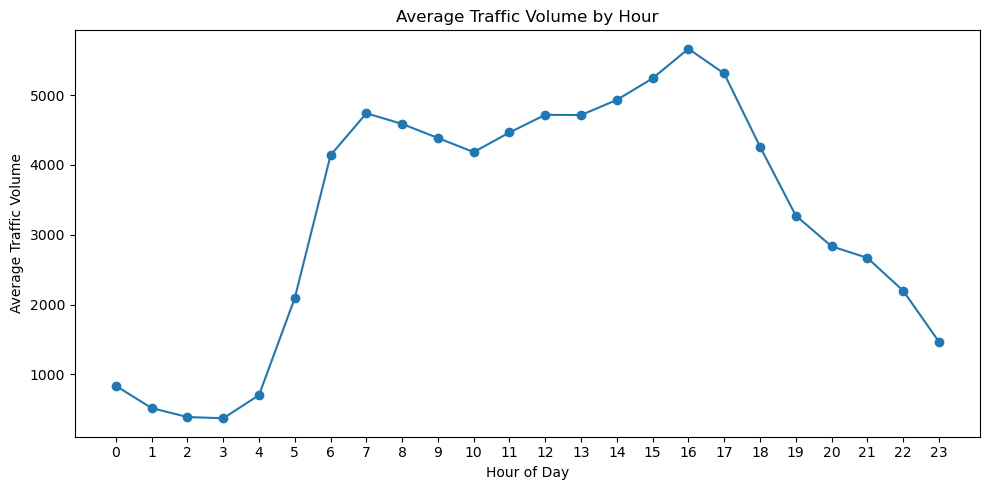

In [43]:
import matplotlib.pyplot as plt

hourly_traffic = (
    cleaned_df
    .groupby("Hour")["traffic_volume"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_traffic.index, hourly_traffic.values, marker="o")

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    "../figures/average_traffic_by_hour.png",
    dpi=300
)

plt.show()

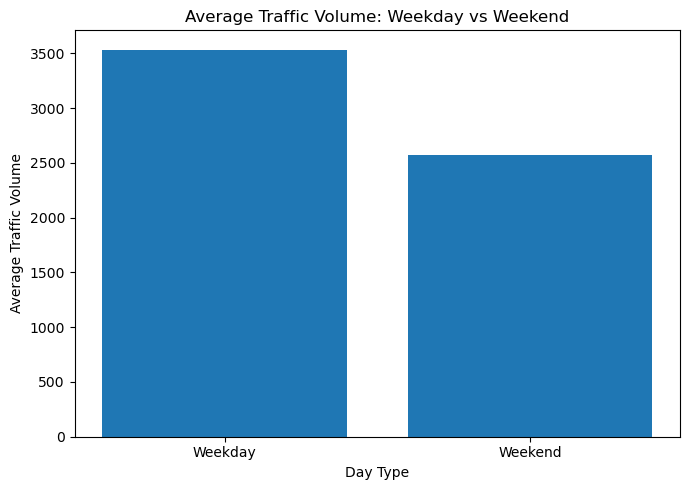

In [44]:
weekend_traffic = (
    cleaned_df
    .groupby("Weekend_Indicator")["traffic_volume"]
    .mean()
)

weekend_traffic.index = ["Weekday", "Weekend"]

plt.figure(figsize=(7, 5))
plt.bar(
    weekend_traffic.index,
    weekend_traffic.values
)

plt.title("Average Traffic Volume: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Traffic Volume")

plt.tight_layout()

plt.savefig(
    "../figures/weekday_vs_weekend_traffic.png",
    dpi=300
)

plt.show()

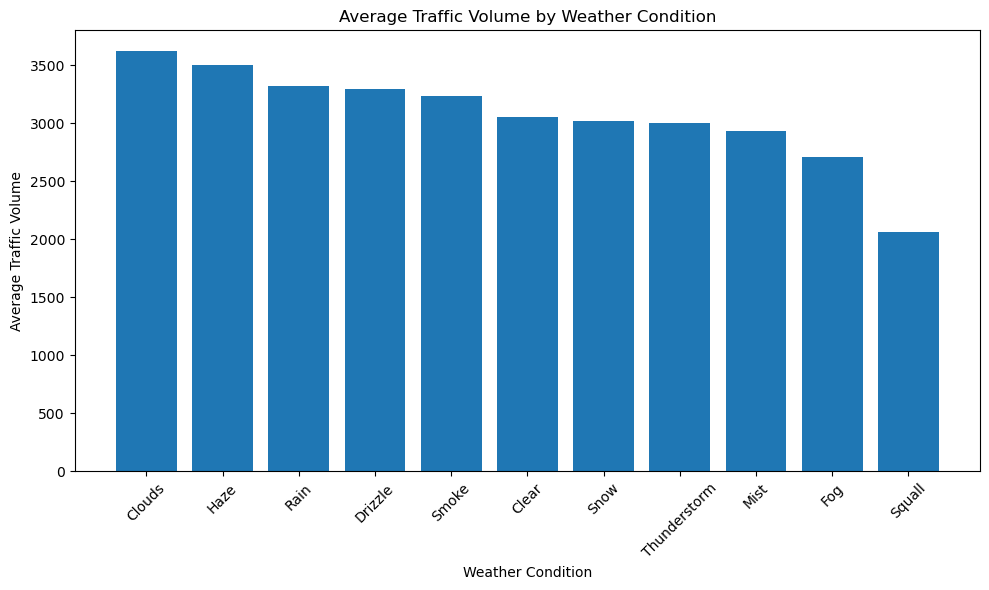

In [45]:
weather_traffic = (
    cleaned_df
    .groupby("weather_main")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(
    weather_traffic.index,
    weather_traffic.values
)

plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../figures/traffic_by_weather_condition.png",
    dpi=300
)

plt.show()

In [46]:
hourly_summary = hourly_traffic.sort_values(ascending=False)

hourly_summary

Hour
16    5663.756539
17    5310.076048
15    5240.459907
14    4931.888776
7     4740.181337
12    4718.031730
13    4714.652836
8     4587.497115
11    4465.569231
9     4385.277502
18    4263.563792
10    4184.135838
6     4140.503594
19    3275.206438
20    2834.667509
21    2668.940464
22    2199.405717
5     2094.573437
23    1469.135294
0      834.984774
4      702.551889
1      516.339033
2      388.353640
3      371.090864
Name: traffic_volume, dtype: float64

### The interpretation for Chart 1

Interpretation: Average traffic volume varies considerably throughout the day. The highest average traffic occurs at 4 PM (Hour 16), with approximately 5,663.76 vehicles, while the lowest occurs at 3 AM (Hour 3), with approximately 371.09 vehicles. This suggests that traffic demand is concentrated during daytime and commuting periods, while traffic is much lower during the early morning hours.

In [48]:
weekend_traffic

Weekday    3533.291791
Weekend    2570.699635
Name: traffic_volume, dtype: float64

### The interpretation for Chart 2
Interpretation: Average traffic volume is higher on weekdays, at approximately 3,533.29 vehicles, compared with approximately 2,570.70 vehicles on weekends. This suggests that weekday commuting and work-related travel contribute to greater traffic demand. For the Smart City Mobility team, this indicates that traffic-management measures may need to focus more heavily on weekdays, especially during peak commuting periods.

In [49]:
weather_traffic

weather_main
Clouds          3617.989115
Haze            3502.101471
Rain            3317.905501
Drizzle         3292.189560
Smoke           3237.650000
Clear           3055.614465
Snow            3016.321391
Thunderstorm    2999.431752
Mist            2933.343923
Fog             2703.720395
Squall          2061.750000
Name: traffic_volume, dtype: float64

### The interpretation for Chart 3
Interpretation: Average traffic volume varies across different weather conditions. Clouds recorded the highest average traffic volume at approximately 3,617.99 vehicles, while Squall recorded the lowest at approximately 2,061.75 vehicles, a difference of about 1,556.24 vehicles. This suggests that weather conditions may be associated with differences in traffic demand. However, the results do not prove that weather directly causes higher or lower traffic because other factors, such as time of day, weekday patterns and commuting behaviour, may also influence traffic volume.

In [50]:
import sys

print(sys.executable)

C:\Users\hengc\anaconda3\python.exe
